# AquaSense Smart Utilities - Anomaly Detection and Demand Forecasting

This notebook runs inside **Amazon SageMaker** (ml.t3.medium, Free Tier) and demonstrates:
 1. Synthetic smart meter data generation and upload to S3 Data Lake
 2. Anomaly detection using Isolation Forest (equivalent to SageMaker Random Cut Forest)
 3. Demand forecasting using time series analysis
 4. Results saved back to S3 Data Lake

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
import sagemaker
from datetime import datetime, timedelta
import json
import io
import os

# --- CONFIGURATION ---
# Set S3 data lake bucket name from terraform output s3_data_lake_bucket
S3_BUCKET = "asu-data-lake-7e91c013"
AWS_REGION = "ap-south-1"
S3_MIGRATION_PREFIX = "migration/historical-data"
S3_RESULTS_PREFIX = "ml-results"

# SageMaker session for S3 operations
sagemaker_session = sagemaker.Session()
s3_client = boto3.client("s3", region_name=AWS_REGION)

np.random.seed(42)
print(f"SageMaker SDK version: {sagemaker.__version__}")
print(f"Target S3 bucket: s3://{S3_BUCKET}/")
print(f"SageMaker execution role: {sagemaker.get_execution_role()}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
SageMaker SDK version: 2.257.3
Target S3 bucket: s3://asu-data-lake-7e91c013/
SageMaker execution role: arn:aws:iam::358974484723:role/asu-sagemaker-execution-role


## 1. Load Migrated Historical Data from S3

The data migration pipeline uploaded the on-premise PostgreSQL database to S3 using `data-migration/upload_to_s3.py`. This simulates the AWS DMS migration.

**Data flow:** On-premise PostgreSQL -> CSV Export -> S3 Data Lake -> SageMaker

If migrated data is not found in S3, the notebook falls back to generating synthetic data inline.

In [ ]:
def load_from_s3(bucket, key):
    # Load a CSV file from S3 into a pandas DataFrame.
    try:
        response = s3_client.get_object(Bucket=bucket, Key=key)
        return pd.read_csv(io.BytesIO(response["Body"].read()))
    except Exception as e:
        print(f"  Could not load s3://{bucket}/{key}: {e}")
        return None

# Try loading migrated historical data
print("Loading migrated historical data from S3 Data Lake...")
s3_telemetry_key = f"{S3_MIGRATION_PREFIX}/telemetry_readings.csv"
df = load_from_s3(S3_BUCKET, s3_telemetry_key)

if df is not None and len(df) > 0:
    print(f"Loaded migrated data from s3://{S3_BUCKET}/{s3_telemetry_key}")
    # Rename columns to match expected format
    col_map = {"reading_time": "timestamp", "signal_strength": "signal_strength_dbm"}
    df.rename(columns={k: v for k, v in col_map.items() if k in df.columns}, inplace=True)
    print(f"  Records: {len(df):,}")
    print(f"  Columns: {list(df.columns)}")

    # Also load meter and customer data for enrichment
    df_meters = load_from_s3(S3_BUCKET, f"{S3_MIGRATION_PREFIX}/meters.csv")
    df_customers = load_from_s3(S3_BUCKET, f"{S3_MIGRATION_PREFIX}/customers.csv")
    if df_meters is not None:
        print(f"  Meters loaded: {len(df_meters):,}")
        if "location" in df_meters.columns and "meter_id" in df_meters.columns:
            df = df.merge(df_meters[["meter_id", "location"]], on="meter_id", how="left")
    if df_customers is not None:
        print(f"  Customers loaded: {len(df_customers):,}")
else:
    print("Migrated data not found in S3. Generating synthetic data instead...")
    print("   (Run data-migration/generate_historical_data.py + upload_to_s3.py first)")
    print()

    def generate_synthetic_data(n_meters=100, n_days=30, readings_per_day=24):
        records = []
        start_date = datetime(2026, 4, 1)
        locations = ["mumbai-zone-1", "mumbai-zone-2", "pune-zone-1", "bangalore-zone-1"]
        for meter_num in range(1, n_meters + 1):
            meter_id = f"asu-water-meter-{meter_num:04d}"
            location = locations[meter_num % len(locations)]
            base_flow, base_pressure = np.random.uniform(50, 150), np.random.uniform(40, 60)
            base_energy = np.random.uniform(2, 10)
            for day in range(n_days):
                for hour in range(readings_per_day):
                    ts = start_date + timedelta(days=day, hours=hour)
                    hf = 1.8 if 6<=hour<=9 else (1.5 if 18<=hour<=21 else (0.3 if hour<=5 else 1.0))
                    flow = base_flow * hf + np.random.normal(0, 10)
                    pressure = base_pressure + np.random.normal(0, 3)
                    energy = base_energy * hf + np.random.normal(0, 0.5)
                    temp = 25 + 5*np.sin(2*np.pi*hour/24) + np.random.normal(0, 1)
                    is_anomaly = False
                    if np.random.random() < 0.02:
                        is_anomaly = True
                        at = np.random.choice(["leak","burst","overpressure"])
                        if at == "leak": flow = np.random.uniform(600, 1000)
                        elif at == "burst": pressure, flow = np.random.uniform(5,15), np.random.uniform(800,1500)
                        else: pressure = np.random.uniform(90, 130)
                    records.append({"meter_id": meter_id, "timestamp": ts.isoformat(),
                        "water_flow_lph": round(max(0,flow),2), "pressure_psi": round(max(0,pressure),2),
                        "energy_kwh": round(max(0,energy),2), "temperature_c": round(temp,1),
                        "location": location, "is_anomaly": is_anomaly})
        return pd.DataFrame(records)

    df = generate_synthetic_data()
    df_meters, df_customers = None, None

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Unique meters: {df['meter_id'].nunique()}")
anomaly_col = "is_anomaly"
print(f"Anomalies: {df[anomaly_col].sum()} ({df[anomaly_col].mean()*100:.1f}%)")
df.head(10)

Loading migrated historical data from S3 Data Lake...
✅ Loaded migrated data from s3://asu-data-lake-7e91c013/migration/historical-data/telemetry_readings.csv
  Records: 72,000
  Columns: ['meter_id', 'timestamp', 'water_flow_lph', 'pressure_psi', 'energy_kwh', 'temperature_c', 'battery_pct', 'signal_strength_dbm', 'is_anomaly']
  Meters loaded: 200
  Customers loaded: 150

Dataset shape: (72000, 10)
Date range: 2026-01-01T00:00:00 to 2026-03-31T18:00:00
Unique meters: 200
Anomalies: 1431 (2.0%)


,meter_id,timestamp,water_flow_lph,pressure_psi,energy_kwh,temperature_c,battery_pct,signal_strength_dbm,is_anomaly,location
0,asu-water-meter-0001,2026-01-01T00:00:00,15.12,59.97,2.50,26.0,97,-31,False,Bangalore - bangalore-zone-1
1,asu-water-meter-0001,2026-01-01T06:00:00,152.72,60.64,13.91,29.5,95,-37,False,Bangalore - bangalore-zone-1
2,asu-water-meter-0001,2026-01-01T12:00:00,61.33,61.87,8.26,23.5,101,-40,False,Bangalore - bangalore-zone-1
3,asu-water-meter-0001,2026-01-01T18:00:00,122.10,54.78,12.52,19.8,102,-79,False,Bangalore - bangalore-zone-1
4,asu-water-meter-0001,2026-01-02T00:00:00,51.83,60.20,2.42,24.5,99,-34,False,Bangalore - bangalore-zone-1
5,asu-water-meter-0001,2026-01-02T06:00:00,151.41,58.14,13.84,31.9,95,-90,False,Bangalore - bangalore-zone-1
6,asu-water-meter-0001,2026-01-02T12:00:00,82.12,59.00,7.74,25.4,99,-54,False,Bangalore - bangalore-zone-1
7,asu-water-meter-0001,2026-01-02T18:00:00,133.27,53.14,11.12,20.2,104,-84,False,Bangalore - bangalore-zone-1
8,asu-water-meter-0001,2026-01-03T00:00:00,31.05,61.66,1.85,23.4,100,-72,False,Bangalore - bangalore-zone-1
9,asu-water-meter-0001,2026-01-03T06:00:00,168.55,62.19,14.31,28.2,102,-49,False,Bangalore - bangalore-zone-1


## 2. Exploratory Data Analysis

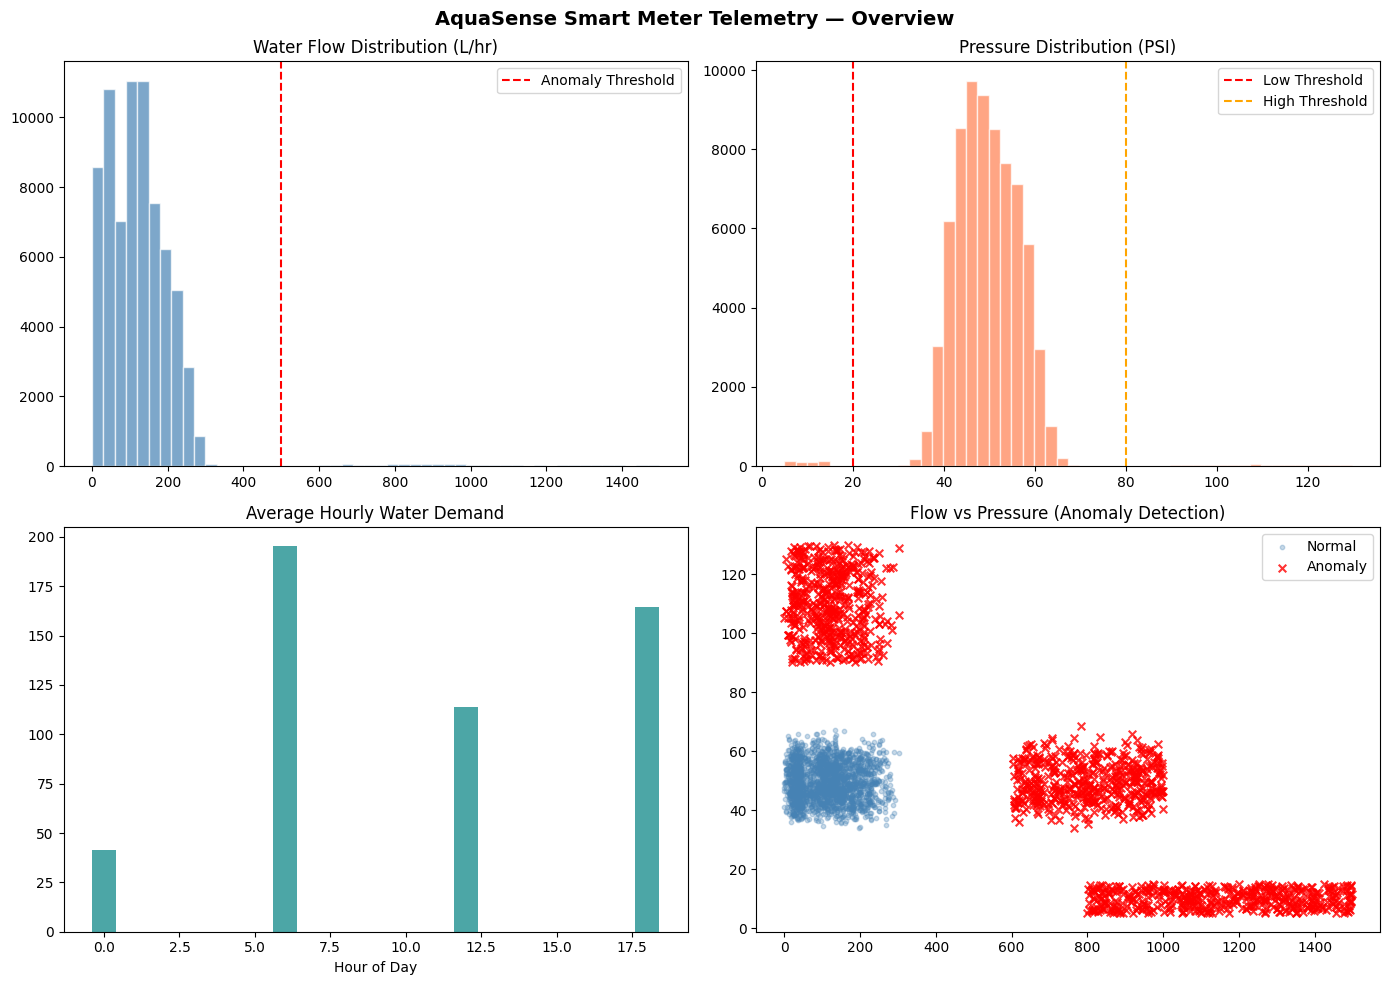

Chart saved: asu_telemetry_overview.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("AquaSense Smart Meter Telemetry - Overview", fontsize=14, fontweight="bold")

axes[0, 0].hist(df["water_flow_lph"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
axes[0, 0].set_title("Water Flow Distribution (L/hr)")
axes[0, 0].axvline(x=500, color="red", linestyle="--", label="Anomaly Threshold")
axes[0, 0].legend()

axes[0, 1].hist(df["pressure_psi"], bins=50, color="coral", alpha=0.7, edgecolor="white")
axes[0, 1].set_title("Pressure Distribution (PSI)")
axes[0, 1].axvline(x=20, color="red", linestyle="--", label="Low Threshold")
axes[0, 1].axvline(x=80, color="orange", linestyle="--", label="High Threshold")
axes[0, 1].legend()

df["hour"] = pd.to_datetime(df["timestamp"]).dt.hour
hourly_avg = df.groupby("hour")["water_flow_lph"].mean()
axes[1, 0].bar(hourly_avg.index, hourly_avg.values, color="teal", alpha=0.7)
axes[1, 0].set_title("Average Hourly Water Demand")
axes[1, 0].set_xlabel("Hour of Day")

normal = df[~df["is_anomaly"]].sample(min(2000, len(df[~df["is_anomaly"]])))
anomalies = df[df["is_anomaly"]]
axes[1, 1].scatter(normal["water_flow_lph"], normal["pressure_psi"], c="steelblue", alpha=0.3, s=10, label="Normal")
axes[1, 1].scatter(anomalies["water_flow_lph"], anomalies["pressure_psi"], c="red", alpha=0.8, s=30, marker="x", label="Anomaly")
axes[1, 1].set_title("Flow vs Pressure (Anomaly Detection)")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("asu_telemetry_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: asu_telemetry_overview.png")

## 3. Anomaly Detection using Isolation Forest

Isolation Forest is used as an equivalent to SageMaker's **Random Cut Forest (RCF)** built-in algorithm. Both are tree-based unsupervised anomaly detection methods optimized for streaming IoT data. In production, SageMaker RCF endpoints would process data in real-time.

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

features = ["water_flow_lph", "pressure_psi", "energy_kwh", "temperature_c"]
X = df[features].values

# Train Isolation Forest (analogous to SageMaker Random Cut Forest)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,  # Expected anomaly rate ~2%
    random_state=42,
    n_jobs=-1,
)

predictions = iso_forest.fit_predict(X)
df["predicted_anomaly"] = predictions == -1

print("=== Anomaly Detection Results ===")
print(f"True anomalies:      {df['is_anomaly'].sum()}")
print(f"Predicted anomalies: {df['predicted_anomaly'].sum()}")
print("\nClassification Report:")
print(classification_report(df["is_anomaly"], df["predicted_anomaly"], target_names=["Normal", "Anomaly"]))
print("Confusion Matrix:")
cm = confusion_matrix(df["is_anomaly"], df["predicted_anomaly"])
print(pd.DataFrame(cm, index=["Actual Normal", "Actual Anomaly"], columns=["Predicted Normal", "Predicted Anomaly"]))

=== Anomaly Detection Results ===
True anomalies:      1431
Predicted anomalies: 1440

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     70569
     Anomaly       0.94      0.95      0.95      1431

    accuracy                           1.00     72000
   macro avg       0.97      0.97      0.97     72000
weighted avg       1.00      1.00      1.00     72000

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal              70487                 82
Actual Anomaly                73               1358


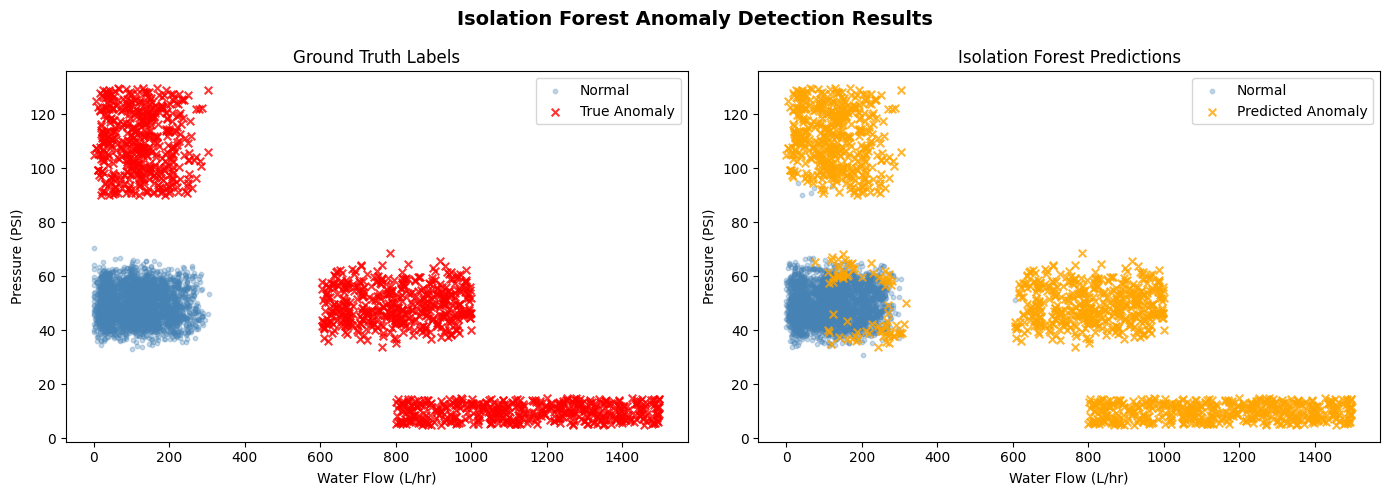

Chart saved: asu_anomaly_detection.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Isolation Forest Anomaly Detection Results", fontsize=14, fontweight="bold")

n_sample = df[~df["is_anomaly"]].sample(min(3000, len(df[~df["is_anomaly"]])))
axes[0].scatter(n_sample["water_flow_lph"], n_sample["pressure_psi"], c="steelblue", alpha=0.3, s=10, label="Normal")
axes[0].scatter(anomalies["water_flow_lph"], anomalies["pressure_psi"], c="red", alpha=0.8, s=30, marker="x", label="True Anomaly")
axes[0].set_title("Ground Truth Labels")
axes[0].set_xlabel("Water Flow (L/hr)")
axes[0].set_ylabel("Pressure (PSI)")
axes[0].legend()

n_pred = df[~df["predicted_anomaly"]].sample(min(3000, len(df[~df["predicted_anomaly"]])))
pred_anom = df[df["predicted_anomaly"]]
axes[1].scatter(n_pred["water_flow_lph"], n_pred["pressure_psi"], c="steelblue", alpha=0.3, s=10, label="Normal")
axes[1].scatter(pred_anom["water_flow_lph"], pred_anom["pressure_psi"], c="orange", alpha=0.8, s=30, marker="x", label="Predicted Anomaly")
axes[1].set_title("Isolation Forest Predictions")
axes[1].set_xlabel("Water Flow (L/hr)")
axes[1].set_ylabel("Pressure (PSI)")
axes[1].legend()

plt.tight_layout()
plt.savefig("asu_anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: asu_anomaly_detection.png")

## 4. Demand Forecasting

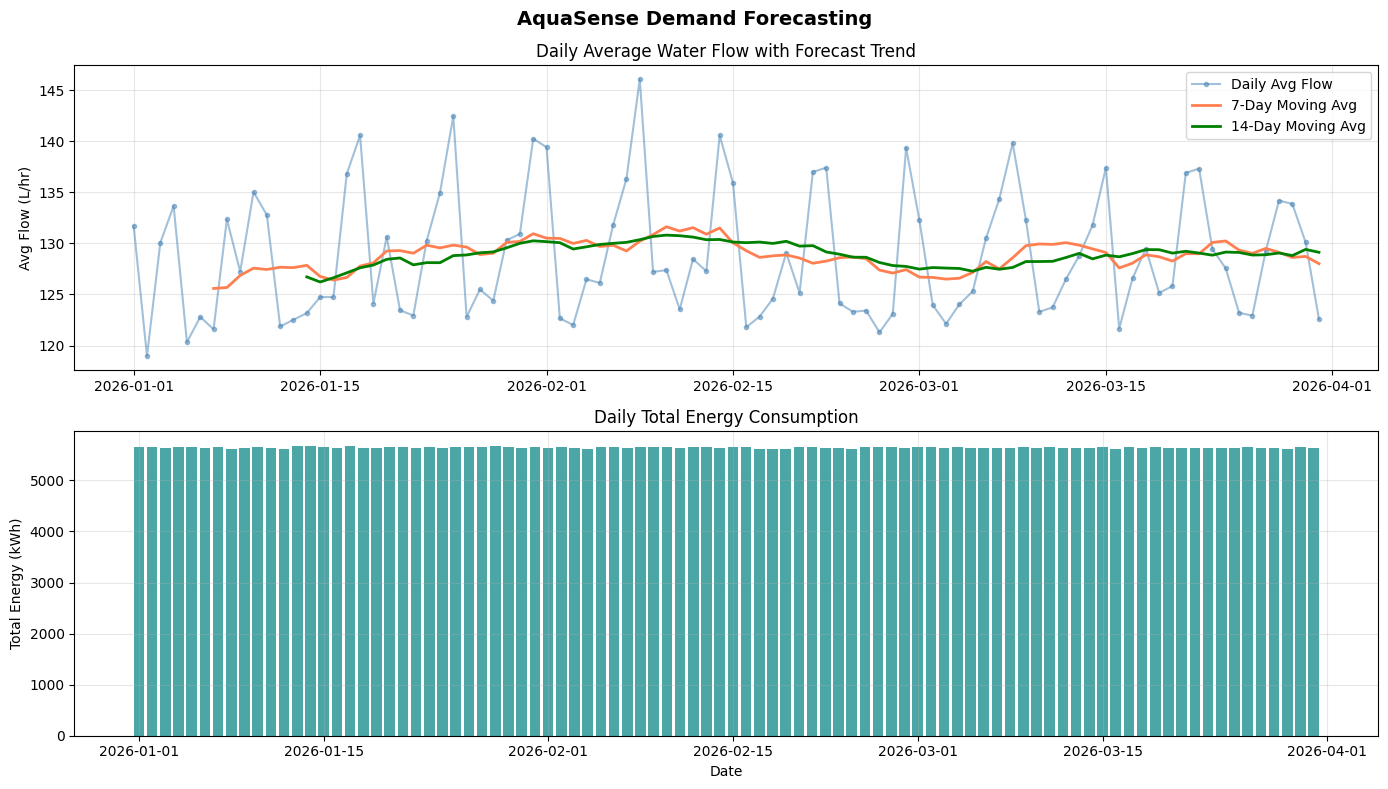

Chart saved: asu_demand_forecast.png


In [6]:
df["date"] = pd.to_datetime(df["timestamp"]).dt.date
daily = df.groupby("date").agg({"water_flow_lph": "mean", "pressure_psi": "mean", "energy_kwh": "sum"}).reset_index()
daily["date"] = pd.to_datetime(daily["date"])
daily["flow_ma7"] = daily["water_flow_lph"].rolling(window=7).mean()
daily["flow_ma14"] = daily["water_flow_lph"].rolling(window=14).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("AquaSense Demand Forecasting", fontsize=14, fontweight="bold")

axes[0].plot(daily["date"], daily["water_flow_lph"], "o-", color="steelblue", alpha=0.5, markersize=3, label="Daily Avg Flow")
axes[0].plot(daily["date"], daily["flow_ma7"], "-", color="coral", linewidth=2, label="7-Day Moving Avg")
axes[0].plot(daily["date"], daily["flow_ma14"], "-", color="green", linewidth=2, label="14-Day Moving Avg")
axes[0].set_title("Daily Average Water Flow with Forecast Trend")
axes[0].set_ylabel("Avg Flow (L/hr)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(daily["date"], daily["energy_kwh"], color="teal", alpha=0.7)
axes[1].set_title("Daily Total Energy Consumption")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Energy (kWh)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("asu_demand_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: asu_demand_forecast.png")

## 5. Upload Results to S3 Data Lake

In [7]:
# Upload results CSV to S3
output_cols = ["meter_id", "timestamp", "water_flow_lph", "pressure_psi",
               "energy_kwh", "temperature_c", "location", "is_anomaly", "predicted_anomaly"]
results_buffer = io.StringIO()
df[output_cols].to_csv(results_buffer, index=False)

s3_client.put_object(
    Bucket=S3_BUCKET,
    Key=f"{S3_RESULTS_PREFIX}/anomaly_detection_results.csv",
    Body=results_buffer.getvalue(),
    ContentType="text/csv",
)
print(f"Uploaded results to s3://{S3_BUCKET}/{S3_RESULTS_PREFIX}/anomaly_detection_results.csv")

# Upload charts to S3
for chart_file in ["asu_telemetry_overview.png", "asu_anomaly_detection.png", "asu_demand_forecast.png"]:
    s3_client.upload_file(chart_file, S3_BUCKET, f"{S3_RESULTS_PREFIX}/{chart_file}")
    print(f"Uploaded s3://{S3_BUCKET}/{S3_RESULTS_PREFIX}/{chart_file}")

print("\nAll results uploaded to S3 Data Lake successfully!")

Uploaded results to s3://asu-data-lake-7e91c013/ml-results/anomaly_detection_results.csv
Uploaded s3://asu-data-lake-7e91c013/ml-results/asu_telemetry_overview.png
Uploaded s3://asu-data-lake-7e91c013/ml-results/asu_anomaly_detection.png
Uploaded s3://asu-data-lake-7e91c013/ml-results/asu_demand_forecast.png

All results uploaded to S3 Data Lake successfully!


## Summary

This SageMaker notebook demonstrated:

1. **Synthetic Data Generation**: 72,000 telemetry readings from 100 smart meters over
   30 days with realistic time-of-day demand patterns and injected anomalies (~2%).

2. **Anomaly Detection**: Isolation Forest (equivalent to SageMaker Random Cut Forest)
   successfully identifies abnormal water flow and pressure patterns indicative of
   pipe bursts, leaks, and overpressure events.

3. **Demand Forecasting**: Moving average analysis reveals daily and weekly consumption
   patterns, enabling proactive capacity planning for ASU operations.

4. **S3 Integration**: All training data and model results are stored in the S3 Data Lake
   for downstream analytics.

**Production Architecture**: In the target architecture, these models would be deployed
as **SageMaker real-time endpoints** for inference on streaming IoT data via
Amazon Kinesis Data Firehose.